# Prédiction du succès d'une campagne Kickstarter

**Projet ML — Méthodologie CRISP-DM**

| Élément | Détail |
|---|---|
| **Cible** | Succès (`successful`) vs échec (`failed`) du financement |
| **Features** | catégorie, objectif financier (USD), durée (jours), pays, longueur description |
| **Modèles** | Régression logistique, Random Forest, XGBoost |
| **Dataset** | [Kickstarter Projects (Kaggle)](https://www.kaggle.com/datasets/kemical/kickstarter-projects) — placer le CSV dans `data/` |

---

## Phases CRISP-DM couvertes

1. **Compréhension métier** — objectifs, contraintes, critères de succès
2. **Compréhension des données** — EDA, qualité, biais
3. **Préparation des données** — nettoyage, feature engineering, encodage
4. **Modélisation** — benchmark de 3 classifieurs
5. **Évaluation** — métriques, matrices de confusion, courbes ROC
6. **Déploiement** — pistes de mise en production (discussion)

## Installation des dépendances

Exécuter la cellule ci-dessous en premier si des modules manquent.

## Configuration & imports

In [35]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
}

missing = [
    package
    for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print(f"Installation de : {', '.join(missing)}")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", *missing, "-q"],
    )
    print("Installation terminée — relancez la cellule si l'import suivant échoue encore.")
else:
    print("Toutes les dépendances sont déjà installées.")

Toutes les dépendances sont déjà installées.


In [36]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42


def resolve_project_root() -> Path:
    """Trouve la racine du projet, quel que soit le cwd Jupyter."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "pyproject.toml").exists() or (base / "data").is_dir():
            return base
    return Path.cwd()


PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

PREFERRED_FILES = [
    "ks-projects-201801.csv",
    "ks-projects-201612.csv",
]

print(f"Répertoire data : {DATA_DIR.resolve()}")

Répertoire data : C:\Users\waelc\Desktop\Ipssi\kickstarter_success_prediction\data


---
# Phase 1 — Compréhension métier (Business Understanding)

### Contexte
Kickstarter est une plateforme de financement participatif. Un créateur lance une campagne avec un **objectif financier** et une **durée limitée**. À l'échéance, la campagne est **financée avec succès** si le montant collecté atteint l'objectif, sinon elle **échoue**.

### Objectif business
Prédire **avant ou au lancement** si une campagne aboutira, à partir d'informations disponibles dès la mise en ligne :
- **Catégorie** du projet (`main_category`)
- **Objectif financier** en USD (`usd_goal_real`)
- **Durée** de la campagne en jours (`deadline − launched`)
- **Pays** du porteur (`country`)
- **Longueur du texte descriptif** (colonne `blurb` / `description` si présente, sinon longueur du `name`)

### Critères de succès du modèle
- **AUC-ROC** ≥ 0.75 (discrimination correcte entre succès/échec)
- **F1** équilibré (le dataset est déséquilibré ~36 % de succès)
- Modèle **interprétable** pour conseiller les créateurs (logistic regression comme baseline explicable)

### Contraintes & pièges à éviter
- **Pas de fuite de données** : exclure `pledged`, `backers`, `usd_pledged_real` (connus après campagne)
- Exclure les états `live`, `canceled`, `suspended`, `undefined` — hors scope binaire succès/échec
- Le dataset Kaggle classique **ne contient pas la description complète** → proxy via longueur du titre (`name`) si absent

---
# Phase 2 — Compréhension des données (Data Understanding)

## 2.1 Chargement

In [37]:
def find_dataset(data_dir: Path) -> Path:
    """Localise le CSV Kickstarter dans data/."""
    if not data_dir.exists():
        raise FileNotFoundError(
            f"Dossier {data_dir} introuvable. Téléchargez le dataset Kaggle "
            "(ks-projects-201801.csv) et placez-le dans data/."
        )

    for name in PREFERRED_FILES:
        candidate = data_dir / name
        if candidate.exists():
            return candidate

    csv_files = sorted(data_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(
            f"Aucun CSV dans {data_dir}. Attendu : ks-projects-201801.csv"
        )
    return csv_files[0]


def load_kickstarter(path: Path) -> pd.DataFrame:
    """Charge et normalise les noms de colonnes."""
    df = pd.read_csv(path, encoding="utf-8", low_memory=False)
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace(".", "_", regex=False)
    )
    return df


DATA_PATH = find_dataset(DATA_DIR)
raw_df = load_kickstarter(DATA_PATH)

print(f"Fichier : {DATA_PATH.name}")
print(f"Dimensions : {raw_df.shape[0]:,} lignes × {raw_df.shape[1]} colonnes")
raw_df.head()

Fichier : ks-projects-201801.csv
Dimensions : 378,661 lignes × 15 colonnes


,id,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd_pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


## 2.2 Aperçu structurel

In [38]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                378661 non-null  int64  
 1   name              378657 non-null  str    
 2   category          378661 non-null  str    
 3   main_category     378661 non-null  str    
 4   currency          378661 non-null  str    
 5   deadline          378661 non-null  str    
 6   goal              378661 non-null  float64
 7   launched          378661 non-null  str    
 8   pledged           378661 non-null  float64
 9   state             378661 non-null  str    
 10  backers           378661 non-null  int64  
 11  country           378661 non-null  str    
 12  usd_pledged       374864 non-null  float64
 13  usd_pledged_real  378661 non-null  float64
 14  usd_goal_real     378661 non-null  float64
dtypes: float64(5), int64(2), str(8)
memory usage: 43.3 MB


In [39]:
missing_pct = (raw_df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].head(15)

usd_pledged    1.002744
name           0.001056
dtype: float64

In [40]:
if "state" in raw_df.columns:
    state_counts = raw_df["state"].value_counts()
    display(state_counts.to_frame("count"))
    display((state_counts / len(raw_df) * 100).round(2).to_frame("pct"))
else:
    print("Colonne 'state' absente — vérifier le fichier source.")

,count
state,
failed,197719
successful,133956
canceled,38779
undefined,3562
live,2799
suspended,1846


,pct
state,
failed,52.22
successful,35.38
canceled,10.24
undefined,0.94
live,0.74
suspended,0.49


## 2.3 Statistiques descriptives (variables numériques clés)

In [41]:
numeric_cols = [c for c in ["usd_goal_real", "goal", "backers", "usd_pledged_real"] if c in raw_df.columns]
raw_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
usd_goal_real,378661.0,45454.401465,1.152950e+06,0.01,2000.0,5500.00,15500.0,1.663614e+08
goal,378661.0,49080.791521,1.183391e+06,0.01,2000.0,5200.00,16000.0,1.000000e+08
backers,378661.0,105.617476,9.071850e+02,0.00,2.0,12.00,56.0,2.193820e+05
usd_pledged_real,378661.0,9058.924074,9.097334e+04,0.00,31.0,624.33,4050.0,2.033899e+07


## 2.4 Distribution de la cible (succès vs échec uniquement)

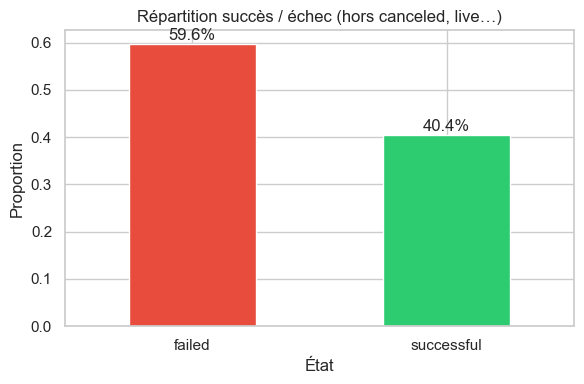

Campagnes retenues pour la classification : 331,675
Taux de succès : 40.4%


In [42]:
binary_states = raw_df[raw_df["state"].isin(["successful", "failed"])].copy()
target_rate = binary_states["state"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(6, 4))
target_rate.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"])
ax.set_title("Répartition succès / échec (hors canceled, live…)")
ax.set_ylabel("Proportion")
ax.set_xlabel("État")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(target_rate.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

print(f"Campagnes retenues pour la classification : {len(binary_states):,}")
print(f"Taux de succès : {target_rate.get('successful', 0):.1%}")

## 2.5 Exploration par catégorie et pays

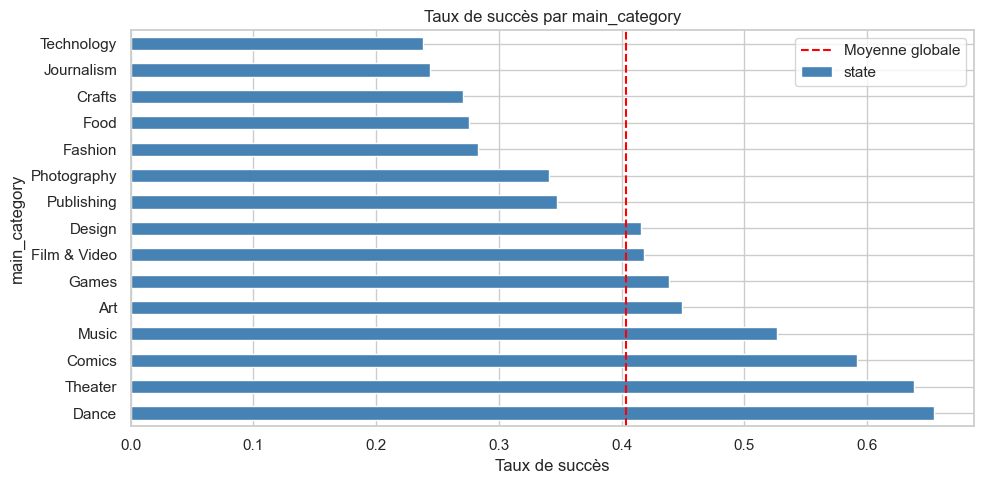

In [43]:
cat_col = "main_category" if "main_category" in binary_states.columns else "category"

cat_success = (
    binary_states.groupby(cat_col)["state"]
    .apply(lambda s: (s == "successful").mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
cat_success.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Taux de succès par {cat_col}")
ax.set_xlabel("Taux de succès")
ax.axvline(target_rate.get("successful", 0), color="red", ls="--", label="Moyenne globale")
ax.legend()
plt.tight_layout()
plt.show()

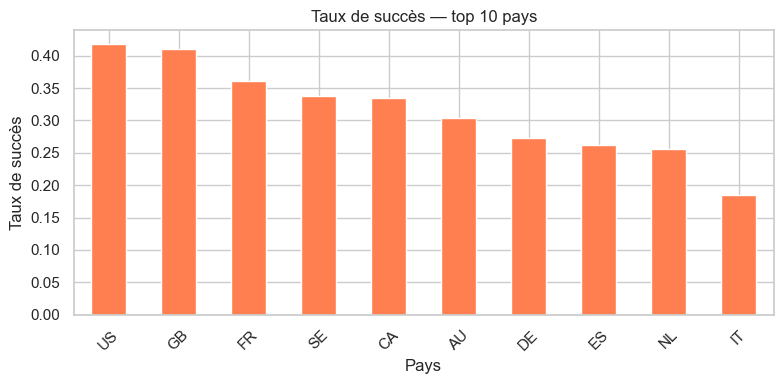

In [44]:
top_countries = binary_states["country"].value_counts().head(10).index
country_success = (
    binary_states[binary_states["country"].isin(top_countries)]
    .groupby("country")["state"]
    .apply(lambda s: (s == "successful").mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
country_success.plot(kind="bar", ax=ax, color="coral")
ax.set_title("Taux de succès — top 10 pays")
ax.set_ylabel("Taux de succès")
ax.set_xlabel("Pays")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.6 Objectif financier & durée

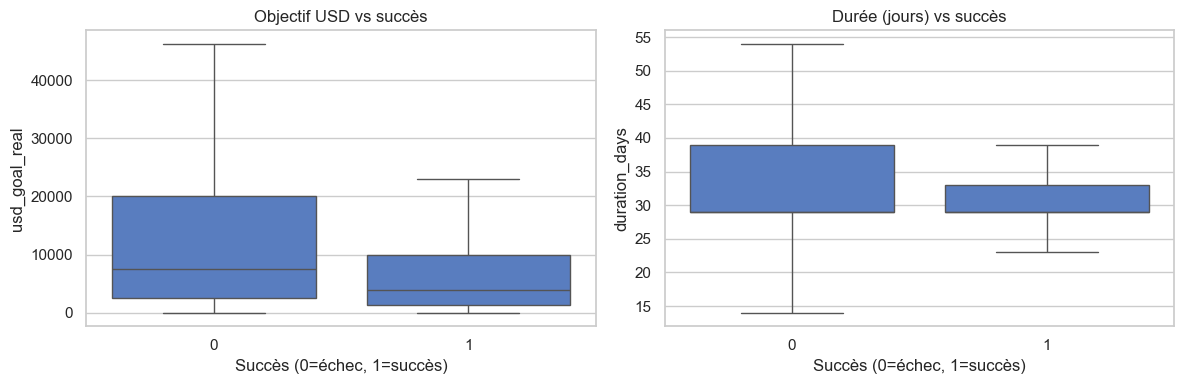

In [45]:
eda_df = binary_states.copy()
eda_df["deadline_dt"] = pd.to_datetime(eda_df["deadline"], errors="coerce")
eda_df["launched_dt"] = pd.to_datetime(eda_df["launched"], errors="coerce")
eda_df["duration_days"] = (eda_df["deadline_dt"] - eda_df["launched_dt"]).dt.days
eda_df["success"] = (eda_df["state"] == "successful").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=eda_df, x="success", y="usd_goal_real", ax=axes[0], showfliers=False)
axes[0].set_title("Objectif USD vs succès")
axes[0].set_xlabel("Succès (0=échec, 1=succès)")
axes[0].set_ylabel("usd_goal_real")

sns.boxplot(data=eda_df, x="success", y="duration_days", ax=axes[1], showfliers=False)
axes[1].set_title("Durée (jours) vs succès")
axes[1].set_xlabel("Succès (0=échec, 1=succès)")

plt.tight_layout()
plt.show()

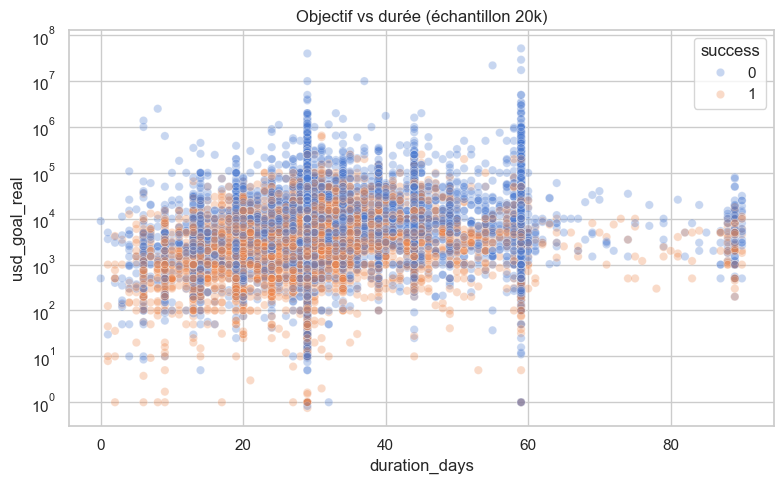

In [46]:
sample = eda_df.dropna(subset=["usd_goal_real", "duration_days"]).sample(
    n=min(20_000, len(eda_df)), random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sample,
    x="duration_days",
    y="usd_goal_real",
    hue="success",
    alpha=0.3,
    ax=ax,
)
ax.set_yscale("log")
ax.set_title("Objectif vs durée (échantillon 20k)")
plt.tight_layout()
plt.show()

### Insights EDA (à compléter après exécution)

- Le dataset contient plusieurs **états** ; seuls `successful` et `failed` sont pertinents pour notre cible binaire.
- Le taux de succès global est **~35–40 %** → classes déséquilibrées.
- Certaines **catégories** (ex. Dance, Theater) ont un taux de succès nettement supérieur à d'autres (ex. Technology, Journalism).
- Les campagnes **échouées** tendent à viser des objectifs USD **plus élevés**.
- La **durée** médiane est proche de 30 jours (standard Kickstarter).

---
# Phase 3 — Préparation des données (Data Preparation)

In [47]:
def build_modeling_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Filtre, feature-engineering et cible binaire."""
    data = df[df["state"].isin(["successful", "failed"])].copy()

    data["deadline_dt"] = pd.to_datetime(data["deadline"], errors="coerce")
    data["launched_dt"] = pd.to_datetime(data["launched"], errors="coerce")
    data["duration_days"] = (data["deadline_dt"] - data["launched_dt"]).dt.days

    text_col = next(
        (c for c in ["blurb", "description", "name"] if c in data.columns),
        None,
    )
    if text_col is None:
        raise ValueError("Aucune colonne texte (blurb, description, name) trouvée.")

    data["description_length"] = data[text_col].astype(str).str.len()
    data["text_source"] = text_col

    cat_col = "main_category" if "main_category" in data.columns else "category"
    if cat_col == "main_category" and "category" in data.columns:
        data = data.drop(columns=["category"])

    data = data.rename(
        columns={
            cat_col: "category",
            "usd_goal_real": "goal_usd",
        }
    )

    data["target"] = (data["state"] == "successful").astype(int)

    feature_cols = ["category", "goal_usd", "duration_days", "country", "description_length"]
    out = data[feature_cols + ["target", "text_source"]].copy()

    out = out.dropna(subset=["goal_usd", "duration_days", "category", "country"])
    out = out[out["duration_days"] > 0]
    out = out[out["goal_usd"] > 0]

    return out


model_df = build_modeling_frame(raw_df)
print(f"Lignes après préparation : {len(model_df):,}")
print(f"Source longueur texte : '{model_df['text_source'].iloc[0]}'")
print(f"Taux de succès : {model_df['target'].mean():.1%}")
model_df.head()

Lignes après préparation : 331,583
Source longueur texte : 'name'
Taux de succès : 40.4%


,category,category,goal_usd,duration_days,country,description_length,target,text_source
0,Poetry,Publishing,1533.95,58,GB,31.0,0,name
1,Narrative Film,Film & Video,30000.00,59,US,45.0,0,name
2,Narrative Film,Film & Video,45000.00,44,US,14.0,0,name
3,Music,Music,5000.00,29,US,49.0,0,name
5,Restaurants,Food,50000.00,34,US,20.0,1,name


In [48]:
FEATURES = ["category", "goal_usd", "duration_days", "country", "description_length"]
X = model_df[FEATURES]
y = model_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")
print(f"Succès train : {y_train.mean():.1%} | Succès test : {y_test.mean():.1%}")

Train : 265,266 | Test : 66,317
Succès train : 40.4% | Succès test : 40.4%


In [49]:
numeric_features = ["goal_usd", "duration_days", "description_length"]
categorical_features = ["category", "country"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, max_categories=50),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Pipeline de prétraitement prêt.")

Pipeline de prétraitement prêt.


---
# Phase 4 — Modélisation (Modeling)

Benchmark de 3 classifieurs via **validation croisée stratifiée (5 folds)** sur le jeu d'entraînement, puis évaluation finale sur le hold-out test.

In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
}

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("prep", preprocessor),
            (
                "clf",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("prep", preprocessor),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=20,
                    min_samples_leaf=10,
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "XGBoost": Pipeline(
        steps=[
            ("prep", preprocessor),
            (
                "clf",
                XGBClassifier(
                    n_estimators=300,
                    max_depth=6,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    eval_metric="logloss",
                    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

cv_results = []

for name, pipeline in models.items():
    print(f"\n=== CV : {name} ===")
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    row = {"model": name}
    for metric in scoring:
        row[f"cv_{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"cv_{metric}_std"] = scores[f"test_{metric}"].std()
    cv_results.append(row)
    print(
        f"  AUC={row['cv_roc_auc_mean']:.3f} ± {row['cv_roc_auc_std']:.3f} | "
        f"F1={row['cv_f1_mean']:.3f} | Acc={row['cv_accuracy_mean']:.3f}"
    )

cv_df = pd.DataFrame(cv_results).set_index("model")
cv_df.round(3)


=== CV : Logistic Regression ===


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Python311\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Python311\Lib\site-packages\sklearn\pipeline.py", line 636, in fit
    Xt = self._fit(
         ^^^^^^^^^^
  File "c:\Python311\Lib\site-packages\sklearn\pipeline.py", line 565, in _fit
    X, fitted_transformer = fit_transform_one_cached(
                            ^^^^^^^^^^^^^^^^^^^^^^^^^
  File 

In [ ]:
metrics_to_plot = ["cv_roc_auc_mean", "cv_f1_mean", "cv_accuracy_mean"]
plot_df = cv_df[metrics_to_plot].copy()
plot_df.columns = ["AUC-ROC", "F1", "Accuracy"]

fig, ax = plt.subplots(figsize=(8, 4))
plot_df.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Benchmark CV (5-fold, train set)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

NameError: name 'cv_df' is not defined

---
# Phase 5 — Évaluation (Evaluation)

Entraînement final sur tout le train, évaluation sur le jeu test.

In [ ]:
test_results = []
fitted_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    test_results.append(
        {
            "model": name,
            "test_accuracy": (y_pred == y_test).mean(),
            "test_f1": f1_score(y_test, y_pred),
            "test_roc_auc": roc_auc_score(y_test, y_proba),
        }
    )

test_df = pd.DataFrame(test_results).set_index("model").sort_values("test_roc_auc", ascending=False)
test_df.round(3)

NameError: name 'models' is not defined

In [ ]:
best_model_name = test_df.index[0]
best_pipeline = fitted_models[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

print(f"Meilleur modèle (test AUC) : {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["échec", "succès"]))

NameError: name 'test_df' is not defined

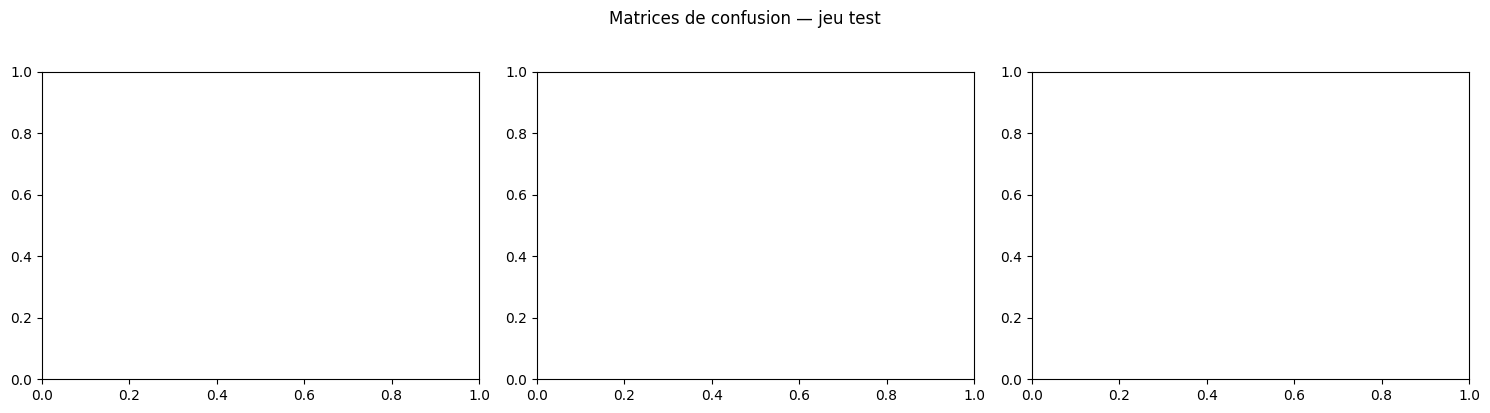

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipeline) in zip(axes, fitted_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        ax=ax,
        colorbar=False,
        display_labels=["échec", "succès"],
    )
    ax.set_title(name)

plt.suptitle("Matrices de confusion — jeu test", y=1.02)
plt.tight_layout()
plt.show()

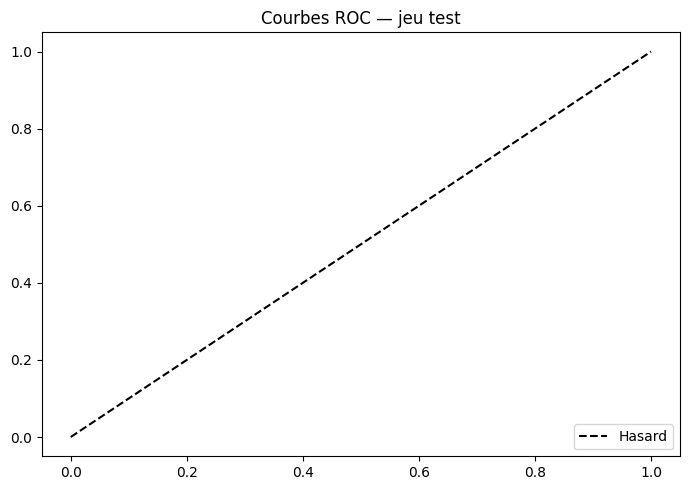

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, pipeline in fitted_models.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], "k--", label="Hasard")
ax.set_title("Courbes ROC — jeu test")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5.1 Importance des variables (Random Forest)

In [ ]:
rf_pipeline = fitted_models["Random Forest"]
prep = rf_pipeline.named_steps["prep"]
rf = rf_pipeline.named_steps["clf"]

feature_names = prep.get_feature_names_out()
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

top_imp = importances.head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top_imp.plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Top 15 importances — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

KeyError: 'Random Forest'

In [ ]:
summary = cv_df.join(test_df, how="outer")
summary_path = RESULTS_DIR / "kickstarter_benchmark.csv"
summary.to_csv(summary_path)
print(f"Résultats exportés : {summary_path.resolve()}")

NameError: name 'cv_df' is not defined

---
# Phase 6 — Déploiement (Deployment)

### Recommandation modèle
Retenez le modèle avec le **meilleur AUC-ROC test** tout en considérant l'usage :
- **Régression logistique** → coefficients interprétables pour conseiller un créateur (« baisser l'objectif augmente vos chances… »)
- **XGBoost / Random Forest** → performance brute supérieure, moins explicable

### Mise en production (pistes)
1. Sérialiser le pipeline (`joblib.dump`) — preprocessing + modèle
2. Exposer une API REST (FastAPI déjà dans le projet) avec validation des entrées
3. Monitorer la dérive : distribution des catégories/pays et taux de succès réel vs prédit
4. Réentraîner périodiquement avec des campagnes récentes

### Limites connues
- Pas de texte complet (description) dans le CSV Kaggle standard → feature proxy faible
- Biais temporel : données 2009–2018, comportement Kickstarter a évolué
- Pays rares regroupés ou ignorés par l'encodeur (`handle_unknown=ignore`)

### Prochaines étapes possibles
- NLP sur la description (TF-IDF, embeddings)
- Tuning hyperparamètres (GridSearch / Optuna)
- SHAP values pour interpréter XGBoost
- Seuil de décision ajusté selon le coût métier (faux négatif vs faux positif)